─── Distribuição de Pedidos por Status ───


Status,Qtd. Pedidos,Distribuição (%)
Entregue,9901,66.4%
Cancelado,2526,16.9%
Em Trânsito,1365,9.1%
Devolvido,1129,7.6%


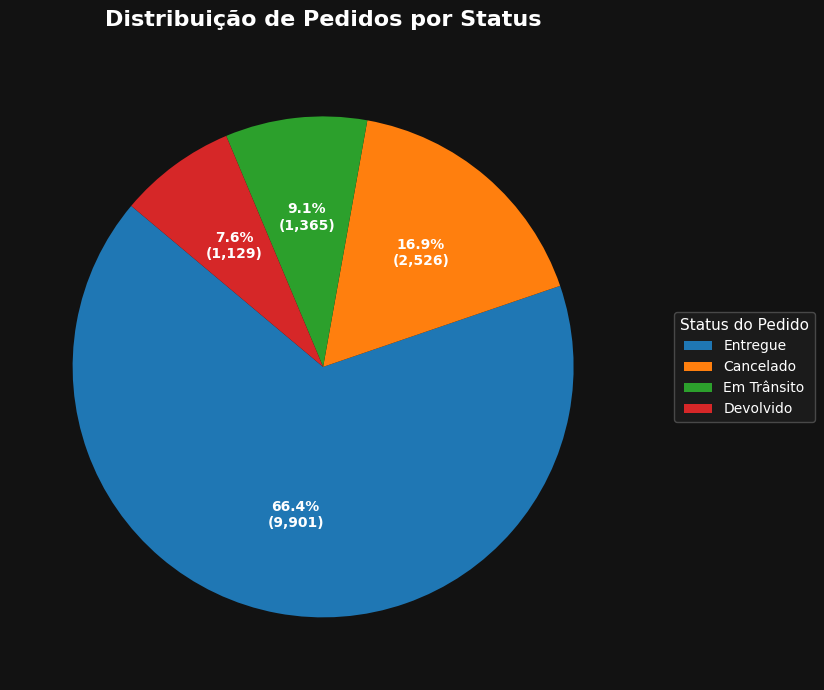

In [ ]:
# 1) Qual o volume de pedidos por status? Calcule a distribuição percentual e apresente os resultados em uma tabela. Inclua uma visualização gráfica (ex: gráfico de barras ou pizza).

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA_DIR = Path('../data')
DARK_BG, GRID_CLR, SPINE_CLR = '#121212', '#333333', '#555555'
COLORS = list(plt.cm.tab10.colors)

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': DARK_BG,
    'text.color': 'white', 'legend.facecolor': '#1e1e1e', 'legend.edgecolor': SPINE_CLR
})

STATUS_LABEL = {
    'em_transito': 'Em Trânsito', 'entregue': 'Entregue', 'cancelado': 'Cancelado',
    'aguardando_pagamento': 'Aguardando Pagamento', 'devolvido': 'Devolvido',
    'fechado': 'Fechado', 'em_andamento': 'Em Andamento', 'aberto': 'Aberto',
}

def pct(valor: float, casas: int = 1) -> str: return f"{valor:.{casas}f}%"
def load_clean(tabela: str) -> pd.DataFrame:
    path = DATA_DIR / f'{tabela}_limpo.csv'
    if not path.exists(): raise FileNotFoundError("Erro: Rode o script ETL (Q6) primeiro.")
    return pd.read_csv(path)

df_pedidos = load_clean('pedidos')

df_pedidos['status_label'] = (
    df_pedidos['status'].map(STATUS_LABEL)
    .fillna(df_pedidos['status'].str.replace('_', ' ').str.title())
)

volume = df_pedidos['status_label'].value_counts()
total  = volume.sum()

tabela_q1 = pd.DataFrame({
    'Status':          volume.index,
    'Qtd. Pedidos':    volume.values,
    'Distribuição (%)': (volume.values / total * 100).round(1),
})
tabela_q1['Distribuição (%)'] = tabela_q1['Distribuição (%)'].apply(pct)

print("─── Distribuição de Pedidos por Status ───")
display(tabela_q1.style.hide(axis='index'))

def _autopct_abs(vals):
    def _fmt(p):
        v = int(round(p * sum(vals) / 100))
        return f'{p:.1f}%\n({v:,})'
    return _fmt

fig, ax = plt.subplots(figsize=(10, 7))
wedges, _, _ = ax.pie(
    volume.values, autopct=_autopct_abs(volume.values),
    startangle=140, colors=COLORS[:len(volume)],
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
ax.legend(
    wedges, volume.index, title='Status do Pedido', title_fontsize=11,
    loc='center left', bbox_to_anchor=(1.05, 0.5), frameon=True,
)
ax.set_title('Distribuição de Pedidos por Status', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()